In [1]:
import pandas as pd

In [2]:
data = pd.read_csv(r'../data/stimulated_data.csv')

In [3]:
# initial analysis

data.shape, data.size, round(data.memory_usage(deep=True).sum()/ (1024 ** 2),2)

((10000, 10), 100000, np.float64(2.93))

- Dataset contain 10000 records and 10 features 
- Total memory used : ~3MB

In [4]:
data.duplicated().sum()

np.int64(0)

- Dataset contain no duplicate records

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           10000 non-null  int64  
 1   age               10000 non-null  int64  
 2   gender            10000 non-null  object 
 3   country           10000 non-null  object 
 4   device            10000 non-null  object 
 5   session_duration  10000 non-null  float64
 6   pages_viewed      10000 non-null  int64  
 7   previous_orders   10000 non-null  int64  
 8   traffic_source    10000 non-null  object 
 9   experiment_group  10000 non-null  object 
dtypes: float64(1), int64(4), object(5)
memory usage: 781.4+ KB


- Dataset features numerical and object data 
- no null present in data

In [6]:
data.describe()

,user_id,age,session_duration,pages_viewed,previous_orders
count,10000.00000,10000.0000,10000.000000,10000.000000,10000.00000
mean,5000.50000,40.9516,3.074873,3.352800,2.00600
std,2886.89568,13.4926,1.622489,2.161666,1.41314
min,1.00000,18.0000,0.460000,1.000000,0.00000
25%,2500.75000,29.0000,1.930000,2.000000,1.00000
50%,5000.50000,41.0000,2.710000,3.000000,2.00000
75%,7500.25000,53.0000,3.830000,4.000000,3.00000
max,10000.00000,64.0000,16.590000,21.000000,9.00000


- people age ranging between 18 - 64, with mean of 40, applears to be balanced distribution
- min session duration of .46 min can mean accidental click or just overview, with average session of 3.07 and max of 16 minutes 
- average pages views ~3, shows potential involvement of users, while some reaching 21 at max but some leave after 1st page as well 
- min previous order of 0 tell some customer are new to website or have never purchased before but can have explored, with mean order of 2.01

In [7]:
num_features = data.select_dtypes(include=['int', 'float']).columns.tolist()
num_features, len(num_features)

(['user_id', 'age', 'session_duration', 'pages_viewed', 'previous_orders'], 5)

In [8]:
cat_features = data.select_dtypes(include='object').columns.tolist()
cat_features, len(cat_features)

(['gender', 'country', 'device', 'traffic_source', 'experiment_group'], 5)

In [9]:
for feature in cat_features:
    print(data[feature].value_counts(), '\n')

gender
Female    6037
Male      3963
Name: count, dtype: int64 

country
India      4875
USA        3063
UK         1000
Brazil      562
Germany     500
Name: count, dtype: int64 

device
Mobile     5978
Desktop    2026
Other      1027
Tablet      969
Name: count, dtype: int64 

traffic_source
Organic    4091
Ads        2954
Email      2013
Social      942
Name: count, dtype: int64 

experiment_group
B    5046
A    4954
Name: count, dtype: int64 



- Majority(~60%) of customer seems to be females while males still having around ~40% density
- Major customer base is from India (~48.7%), followed by USA (30.6%), UK (10%), Brazil(5.6%) and lastly Germany having only 5%
- Mobile (~60%) is most used device while followed by desktop (20%), tablets (10%), other may refer to laptops, smart tvs, etc.
- organic is major source of customer traffic, while ads at second and email at third, making social at last with 9%
- Experiment group represent the result of before and after change cusotmer category 

#### Initail Summary

- The customer base is female-dominant, with India contributing the largest share of users in the simulated dataset.
- Organic traffic is the largest acquisition channel, suggesting customers primarily discover the platform through unpaid sources such as search engines. This may indicate effective SEO or strong brand visibility.
- Most users access the platform via mobile devices, reflecting the growing preference for mobile shopping.

- A considerable portion of users are first-time visitors or first-time buyers,
- The average session duration is approximately 3 minutes, Short sessions may indicate either efficient navigation or early exits. Further analysis is required to determine whether this reflects efficient shopping behavior or early customer drop-off.
- Browsing behavior varies considerably. While some users leave after viewing a single page, others explore more than 20 pages, indicating diverse shopping behaviors ranging from quick visits to extensive product exploration.

### Relation Analysis

#### Correlation Matrix

In [10]:
data[num_features].drop(columns='user_id').corr()

,age,session_duration,pages_viewed,previous_orders
age,1.000000,-0.001151,-0.003015,0.005565
session_duration,-0.001151,1.000000,-0.014973,-0.002413
pages_viewed,-0.003015,-0.014973,1.000000,-0.008158
previous_orders,0.005565,-0.002413,-0.008158,1.000000


- Observation:

    The correlation coefficients between numerical features are all close to zero.

- Interpretation:

    No meaningful linear relationships exist among the numerical variables.

- Reason:

    This aligns with the data generation process, where numerical features were simulated independently.

#### Business analysis

In [11]:
data.columns.tolist()

['user_id',
 'age',
 'gender',
 'country',
 'device',
 'session_duration',
 'pages_viewed',
 'previous_orders',
 'traffic_source',
 'experiment_group']

In [18]:
# Effect of traffic on other features

<Axes: xlabel='traffic_source'>

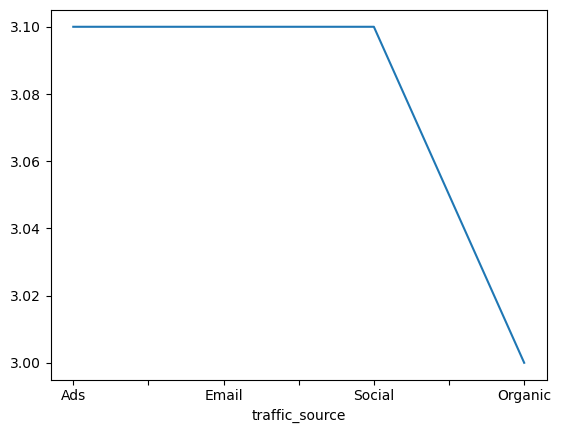

In [15]:
round(data.groupby('traffic_source')['session_duration'].mean().sort_values(ascending=False),1).plot(kind='line')

<Axes: xlabel='traffic_source'>

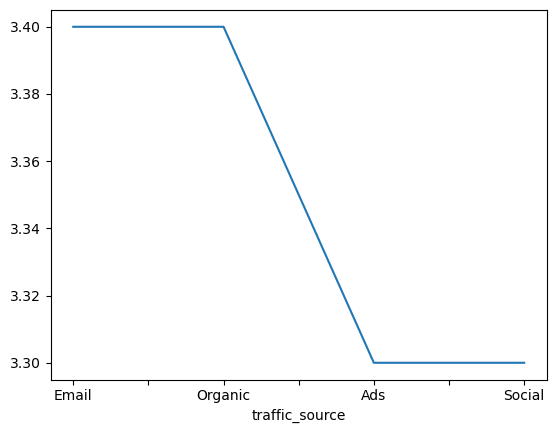

In [16]:
round(data.groupby('traffic_source')['pages_viewed'].mean().sort_values(ascending=False),1).plot(kind='line')

<Axes: xlabel='traffic_source'>

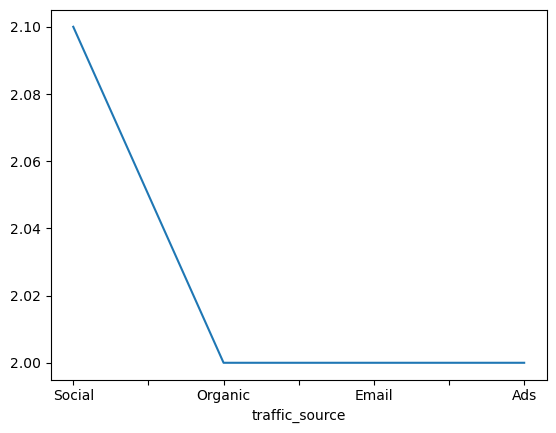

In [17]:
round(data.groupby('traffic_source')['previous_orders'].mean().sort_values(ascending=False),1).plot(kind='line')

- Conclusion : 

    No substantial differences were observed in user behavior across traffic sources.

In [19]:
# Device analysis 

<Axes: xlabel='device'>

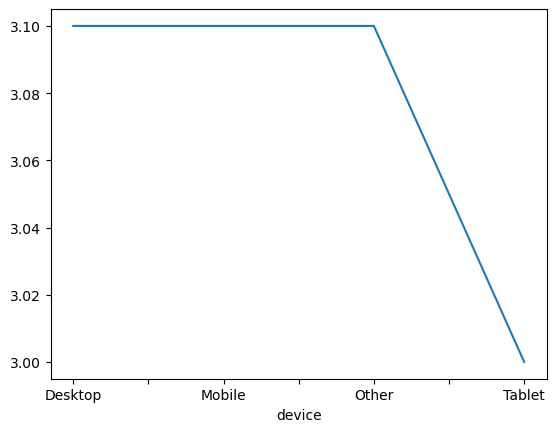

In [23]:
round(data.groupby('device')['session_duration'].mean(),1).sort_values(ascending=False).plot(kind='line')

<Axes: xlabel='device'>

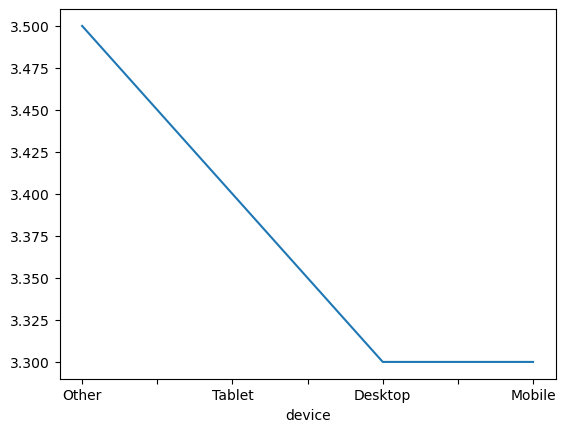

In [32]:
round(data.groupby('device')['pages_viewed'].mean(),1).sort_values(ascending=False).plot(kind='line')

<Axes: xlabel='device'>

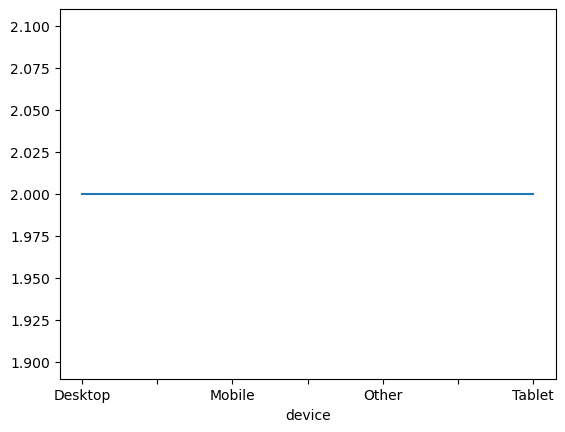

In [24]:
round(data.groupby('device')['previous_orders'].mean(),1).sort_values(ascending=False).plot(kind='line')

In [25]:
# Coutnry analysis

In [34]:
round(data.groupby(['country', 'gender'])['session_duration'].mean(),1).unstack()

gender,Female,Male
country,,
Brazil,3.0,3.2
Germany,3.1,3.0
India,3.1,3.1
UK,3.1,2.9
USA,3.1,3.0


<Axes: xlabel='country'>

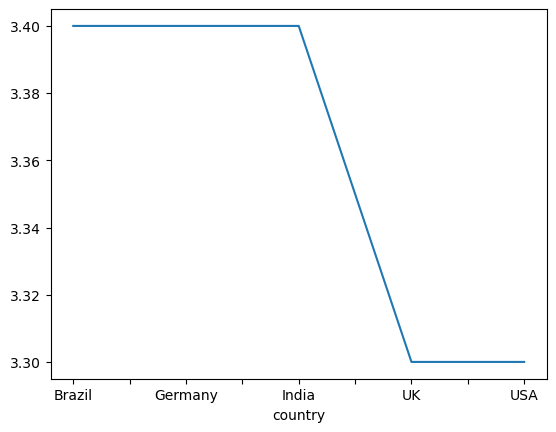

In [33]:
round(data.groupby('country')['pages_viewed'].mean(),1).sort_values(ascending=False).plot(kind='line')

<Axes: xlabel='country'>

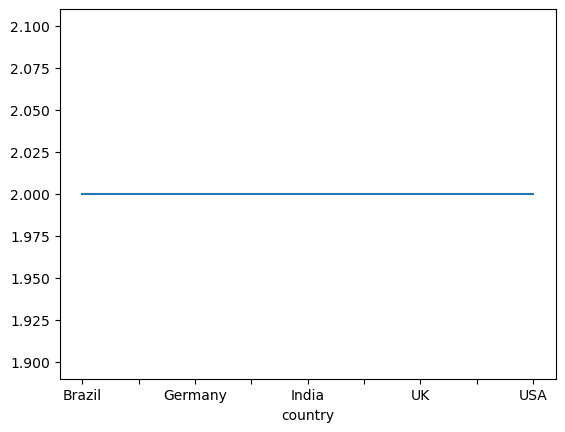

In [27]:
round(data.groupby('country')['previous_orders'].mean(),1).sort_values(ascending=False).plot(kind='line')

- Business Segment Analysis: 

    Across traffic sources, devices, countries, and gender groups, no meaningful differences in customer behavior were observed. This outcome is consistent with the independent feature generation used during data simulation. More realistic behavioral differences will be introduced in the subsequent customer behavior simulation phase.